# 04 — Baseline Model (ResNet-18)
### Dataset: FaceForensics++ (C23) | Cross-Dataset: Celeb-DF v2
This notebook covers:
- ResNet-18 as the baseline binary deepfake detection model
- Temporal average pooling across 16 uniformly sampled frames
- Full dataset training with WeightedRandomSampler
- Evaluation on FF++ test set with confusion matrix and ROC curve
- Zero-shot cross-dataset evaluation on Celeb-DF v2
- Generalization gap analysis between FF++ and Celeb-DF v2
- Model and results saved to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import gc
import copy
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
import cv2
import numpy as np

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

Mounted at /content/drive
All libraries imported successfully.
PyTorch version : 2.10.0+cu128
CUDA available  : True


In [2]:
# Reload project paths and constants to make this notebook fully self-contained
PROJECT_ROOT = Path("/content/drive/MyDrive/deepfake_binary_project")

PROC_ROOT  = PROJECT_ROOT / "processed"
INDEX_DIR  = PROJECT_ROOT / "index"
MODEL_DIR  = PROJECT_ROOT / "models"

FFPP_FACES_ROOT    = PROC_ROOT / "ffpp_face_crops_224"
CELEBDF_FACES_ROOT = PROC_ROOT / "celebdf_face_crops_224"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED        = 42
NUM_FRAMES  = 16
IMG_SIZE    = 224
BATCH_SIZE  = 8
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)

print(f"Device         : {device} ({torch.cuda.get_device_name(0)})")
print(f"Frames/video   : {NUM_FRAMES}")
print(f"Image size     : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Model dir      : {MODEL_DIR}")

Device         : cuda (Tesla T4)
Frames/video   : 16
Image size     : 224x224
Batch size     : 8
Model dir      : /content/drive/MyDrive/deepfake_binary_project/models


In [3]:
# Load pre-built split index files generated in notebook 01
train_df   = pd.read_csv(INDEX_DIR / "ffpp_train.csv")
val_df     = pd.read_csv(INDEX_DIR / "ffpp_val.csv")
test_df    = pd.read_csv(INDEX_DIR / "ffpp_test.csv")
df_celebdf = pd.read_csv(INDEX_DIR / "celebdf_test.csv")

print("Index files loaded successfully.")
print(f"\nFF++ Train : {len(train_df)} videos  (real: {(train_df.binary_target==0).sum()} | fake: {(train_df.binary_target==1).sum()})")
print(f"FF++ Val   : {len(val_df)} videos  (real: {(val_df.binary_target==0).sum()} | fake: {(val_df.binary_target==1).sum()})")
print(f"FF++ Test  : {len(test_df)} videos  (real: {(test_df.binary_target==0).sum()} | fake: {(test_df.binary_target==1).sum()})")
print(f"\nCeleb-DF v2: {len(df_celebdf)} videos  (real: {(df_celebdf.binary_target==0).sum()} | fake: {(df_celebdf.binary_target==1).sum()})")

Index files loaded successfully.

FF++ Train : 4200 videos  (real: 700 | fake: 3500)
FF++ Val   : 900 videos  (real: 150 | fake: 750)
FF++ Test  : 900 videos  (real: 150 | fake: 750)

Celeb-DF v2: 6529 videos  (real: 890 | fake: 5639)


In [4]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=10),
    T.RandomGrayscale(p=0.02),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class DeepfakeDataset(Dataset):
    """
    Loads pre-extracted MTCNN face crops and applies the specified transform.
    Returns a tensor of shape (T, C, H, W) and a binary label.
    """
    def __init__(self, df, faces_root, transform=None, num_frames=NUM_FRAMES):
        self.df         = df.reset_index(drop=True)
        self.faces_root = Path(faces_root)
        self.transform  = transform
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        vid_stem  = Path(row["path"]).stem
        label     = int(row["binary_target"])
        frame_dir = self.faces_root / row["binary_label"] / vid_stem

        frames = []
        for i in range(self.num_frames):
            img = cv2.imread(str(frame_dir / f"frame_{i:02d}.jpg"))
            if img is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                img = self.transform(img)
            else:
                img = T.Compose([T.ToPILImage(), T.ToTensor()])(img)
            frames.append(img)

        return torch.stack(frames), torch.tensor(label, dtype=torch.long)

print("Transforms and DeepfakeDataset class defined.")

Transforms and DeepfakeDataset class defined.


In [5]:
train_dataset      = DeepfakeDataset(train_df,   FFPP_FACES_ROOT,    transform=train_transform)
val_dataset        = DeepfakeDataset(val_df,     FFPP_FACES_ROOT,    transform=val_transform)
test_dataset       = DeepfakeDataset(test_df,    FFPP_FACES_ROOT,    transform=val_transform)
celebdf_dataset    = DeepfakeDataset(df_celebdf, CELEBDF_FACES_ROOT, transform=val_transform)

# WeightedRandomSampler to handle 1:5 real-to-fake class imbalance
targets = train_df["binary_target"].values
counts  = np.bincount(targets)
weights = 1.0 / counts[targets]

sampler = WeightedRandomSampler(
    weights     = torch.tensor(weights, dtype=torch.float),
    num_samples = len(weights),
    replacement = True
)

train_loader   = DataLoader(train_dataset,   batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True)
val_loader     = DataLoader(val_dataset,     batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
test_loader    = DataLoader(test_dataset,    batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
celebdf_loader = DataLoader(celebdf_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train dataset      : {len(train_dataset)} videos  | {len(train_loader)} batches")
print(f"Val dataset        : {len(val_dataset)} videos  | {len(val_loader)} batches")
print(f"Test dataset       : {len(test_dataset)} videos  | {len(test_loader)} batches")
print(f"Celeb-DF dataset   : {len(celebdf_dataset)} videos | {len(celebdf_loader)} batches")
print(f"\nSampler            : WeightedRandomSampler (replacement=True)")
print(f"Real weight        : {weights[targets==0][0]:.4f}")
print(f"Fake weight        : {weights[targets==1][0]:.4f}")

Train dataset      : 4200 videos  | 525 batches
Val dataset        : 900 videos  | 113 batches
Test dataset       : 900 videos  | 113 batches
Celeb-DF dataset   : 6529 videos | 817 batches

Sampler            : WeightedRandomSampler (replacement=True)
Real weight        : 0.0014
Fake weight        : 0.0003


## Part 1 — ResNet-18 Model Definition
ResNet-18 is used as the baseline model. Frames are processed independently
through the ResNet-18 backbone and temporal average pooling is applied across
all 16 frames to produce a single video-level feature vector for classification.

In [6]:
class ResNet18DeepfakeDetector(nn.Module):
    """
    ResNet-18 baseline for binary deepfake detection.
    Processes each frame independently and aggregates via temporal average pooling.
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Remove the final classification layer
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.dropout           = nn.Dropout(dropout)
        self.classifier        = nn.Linear(512, 2)

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x        = x.view(B * T, C, H, W)
        features = self.feature_extractor(x)       # (B*T, 512, 1, 1)
        features = features.flatten(1)             # (B*T, 512)
        features = features.view(B, T, 512).mean(dim=1)  # temporal average pooling
        features = self.dropout(features)
        return self.classifier(features)           # (B, 2)

torch.cuda.empty_cache()
gc.collect()

model = ResNet18DeepfakeDetector(dropout=0.3).to(device)

# Shape verification
with torch.no_grad():
    dummy = torch.randn(2, NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(device)
    out   = model(dummy)

print(f"Input shape  : {dummy.shape}")
print(f"Output shape : {out.shape}")
print(f"GPU memory   : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Input shape  : torch.Size([2, 16, 3, 224, 224])
Output shape : torch.Size([2, 2])
GPU memory   : 0.07 GB


## Part 2 — Training Pipeline

In [7]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for frames, labels in loader:
        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(frames)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        probs = torch.softmax(outputs.detach(), dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.detach().argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
    }


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(frames)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return {
        "loss"     : running_loss / len(loader.dataset),
        "acc"      : accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "f1"       : f1_score(all_labels, all_preds, zero_division=0),
        "auc"      : roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0,
        "y_true"   : all_labels,
        "y_pred"   : all_preds,
        "y_prob"   : all_probs,
    }


def print_epoch(epoch, total, tr, val, lr, t):
    print(f"Epoch [{epoch}/{total}]")
    print(f"  Train  loss={tr['loss']:.4f}  acc={tr['acc']:.4f}  f1={tr['f1']:.4f}  auc={tr['auc']:.4f}")
    print(f"  Val    loss={val['loss']:.4f}  acc={val['acc']:.4f}  f1={val['f1']:.4f}  auc={val['auc']:.4f}")
    print(f"  LR={lr:.6f}  time={t/60:.2f} min")
    print("-" * 65)


print("Training utilities defined.")

Training utilities defined.


In [8]:
resnet_path = MODEL_DIR / "resnet18_best.pth"

if resnet_path.exists():
    model.load_state_dict(torch.load(resnet_path, map_location=device))
    print("ResNet-18 weights loaded from Drive — skipping training.")
else:
    EPOCHS    = 10
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2)

    history  = {"train": [], "val": []}
    best_f1  = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    print("=" * 65)
    print("ResNet-18 — Training on full FF++ dataset")
    print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | Frames: {NUM_FRAMES}")
    print("=" * 65)

    for epoch in range(1, EPOCHS + 1):
        t0      = time.time()
        train_m = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_m   = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_m["f1"])
        history["train"].append(train_m)
        history["val"].append(val_m)

        if val_m["f1"] > best_f1:
            best_f1  = val_m["f1"]
            best_wts = copy.deepcopy(model.state_dict())

        print_epoch(epoch, EPOCHS, train_m, val_m,
                    optimizer.param_groups[0]["lr"], time.time() - t0)
        torch.cuda.empty_cache()
        gc.collect()

    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), resnet_path)
    print(f"\nTraining complete. Best val F1 : {best_f1:.4f}")
    print(f"Model saved to : {resnet_path}")

ResNet-18 weights loaded from Drive — skipping training.


## Part 3 — Evaluation on FF++ Test Set

In [9]:
print("Evaluating ResNet-18 on FF++ test set...")
test_m = evaluate(model, test_loader, criterion, device)

print(f"\nFF++ Test Results:")
print(f"  Loss      : {test_m['loss']:.4f}")
print(f"  Accuracy  : {test_m['acc']:.4f}")
print(f"  Precision : {test_m['precision']:.4f}")
print(f"  Recall    : {test_m['recall']:.4f}")
print(f"  F1-Score  : {test_m['f1']:.4f}")
print(f"  AUC       : {test_m['auc']:.4f}")

Evaluating ResNet-18 on FF++ test set...

FF++ Test Results:
  Loss      : 0.0038
  Accuracy  : 0.9989
  Precision : 0.9987
  Recall    : 1.0000
  F1-Score  : 0.9993
  AUC       : 1.0000


Classification Report — FF++ Test Set:

              precision    recall  f1-score   support

        real       1.00      0.99      1.00       150
        fake       1.00      1.00      1.00       750

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



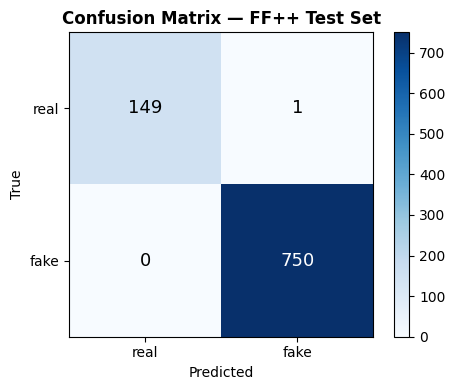

In [10]:
print("Classification Report — FF++ Test Set:\n")
print(classification_report(test_m["y_true"], test_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm = confusion_matrix(test_m["y_true"], test_m["y_pred"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)

ax.set_title("Confusion Matrix — FF++ Test Set", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "eda_plots" / "13_resnet18_ffpp_cm.png"),
            dpi=150, bbox_inches="tight")
plt.show()

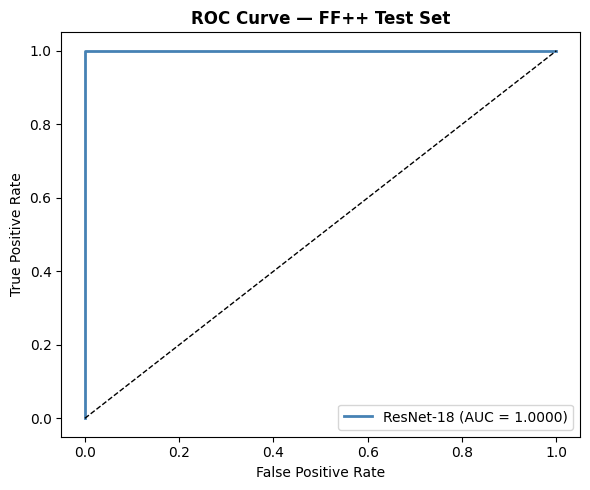

In [11]:
fpr, tpr, _ = roc_curve(test_m["y_true"], test_m["y_prob"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ResNet-18 (AUC = {test_m['auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — FF++ Test Set", fontweight="bold")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "eda_plots" / "14_resnet18_ffpp_roc.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Part 4 — Zero-Shot Cross-Dataset Evaluation on Celeb-DF v2
The model is evaluated on Celeb-DF v2 without any fine-tuning to measure
cross-dataset generalisation — the key limitation this project aims to address.

In [12]:
print("Evaluating ResNet-18 on Celeb-DF v2 (zero-shot)...")
celebdf_m = evaluate(model, celebdf_loader, criterion, device)

print(f"\nCeleb-DF v2 Results:")
print(f"  Loss      : {celebdf_m['loss']:.4f}")
print(f"  Accuracy  : {celebdf_m['acc']:.4f}")
print(f"  Precision : {celebdf_m['precision']:.4f}")
print(f"  Recall    : {celebdf_m['recall']:.4f}")
print(f"  F1-Score  : {celebdf_m['f1']:.4f}")
print(f"  AUC       : {celebdf_m['auc']:.4f}")

Evaluating ResNet-18 on Celeb-DF v2 (zero-shot)...

Celeb-DF v2 Results:
  Loss      : 2.1287
  Accuracy  : 0.5243
  Precision : 0.9745
  Recall    : 0.4613
  F1-Score  : 0.6261
  AUC       : 0.8282


In [13]:
# Save Celeb-DF evaluation results to Drive immediately
celebdf_results = {
    "loss"     : float(celebdf_m["loss"]),
    "acc"      : float(celebdf_m["acc"]),
    "precision": float(celebdf_m["precision"]),
    "recall"   : float(celebdf_m["recall"]),
    "f1"       : float(celebdf_m["f1"]),
    "auc"      : float(celebdf_m["auc"]),
    "y_true"   : [int(x) for x in celebdf_m["y_true"]],
    "y_pred"   : [int(x) for x in celebdf_m["y_pred"]],
    "y_prob"   : [float(x) for x in celebdf_m["y_prob"]],
}

with open(PROJECT_ROOT / "models" / "resnet18_celebdf_results.json", "w") as f:
    json.dump(celebdf_results, f)

print("Celeb-DF results saved to Drive.")

Celeb-DF results saved to Drive.


Classification Report — Celeb-DF v2 (Zero-Shot):

              precision    recall  f1-score   support

        real       0.21      0.92      0.35       890
        fake       0.97      0.46      0.63      5639

    accuracy                           0.52      6529
   macro avg       0.59      0.69      0.49      6529
weighted avg       0.87      0.52      0.59      6529



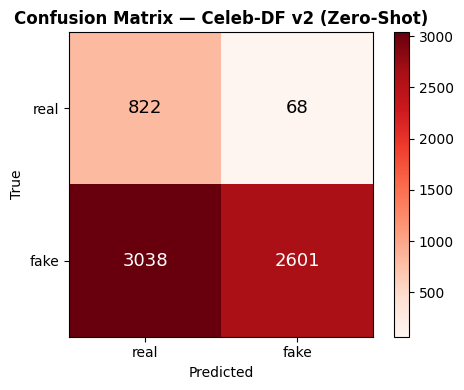

In [14]:
print("Classification Report — Celeb-DF v2 (Zero-Shot):\n")
print(classification_report(celebdf_m["y_true"], celebdf_m["y_pred"],
                             target_names=["real", "fake"], zero_division=0))

cm_celeb = confusion_matrix(celebdf_m["y_true"], celebdf_m["y_pred"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_celeb, interpolation="nearest", cmap="Reds")
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_xticklabels(["real", "fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real", "fake"])

for i in range(cm_celeb.shape[0]):
    for j in range(cm_celeb.shape[1]):
        ax.text(j, i, str(cm_celeb[i, j]), ha="center", va="center",
                color="white" if cm_celeb[i, j] > cm_celeb.max() / 2 else "black",
                fontsize=13)

ax.set_title("Confusion Matrix — Celeb-DF v2 (Zero-Shot)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "eda_plots" / "15_resnet18_celebdf_cm.png"),
            dpi=150, bbox_inches="tight")
plt.show()

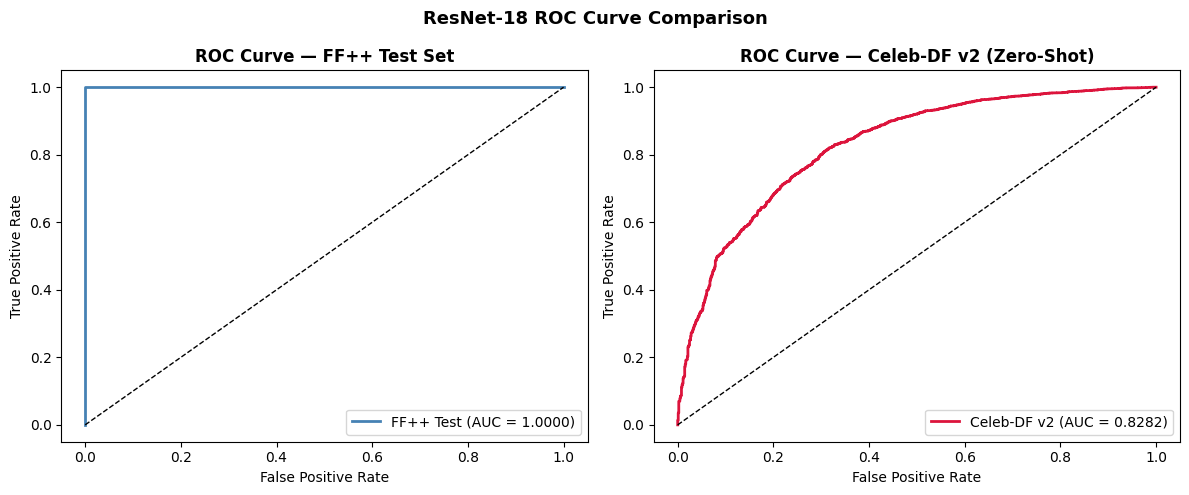

Generalization Gap (Δgen) : 0.1718
  FF++ AUC     : 1.0000
  Celeb-DF AUC : 0.8282


In [15]:
fpr_ff, tpr_ff, _     = roc_curve(test_m["y_true"], test_m["y_prob"])
fpr_cd, tpr_cd, _     = roc_curve(celebdf_m["y_true"], celebdf_m["y_prob"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# FF++ ROC
axes[0].plot(fpr_ff, tpr_ff, color="steelblue", lw=2,
             label=f"FF++ Test (AUC = {test_m['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve — FF++ Test Set", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# Celeb-DF v2 ROC
axes[1].plot(fpr_cd, tpr_cd, color="crimson", lw=2,
             label=f"Celeb-DF v2 (AUC = {celebdf_m['auc']:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve — Celeb-DF v2 (Zero-Shot)", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.suptitle("ResNet-18 ROC Curve Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "eda_plots" / "16_resnet18_roc_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

gen_gap = test_m["auc"] - celebdf_m["auc"]
print(f"Generalization Gap (Δgen) : {gen_gap:.4f}")
print(f"  FF++ AUC     : {test_m['auc']:.4f}")
print(f"  Celeb-DF AUC : {celebdf_m['auc']:.4f}")

## Part 5 — Generalization Gap Summary

In [16]:
results = {
    "model"        : "ResNet-18",
    "ffpp_test"    : {
        "loss"     : float(test_m["loss"]),
        "accuracy" : float(test_m["acc"]),
        "precision": float(test_m["precision"]),
        "recall"   : float(test_m["recall"]),
        "f1"       : float(test_m["f1"]),
        "auc"      : float(test_m["auc"]),
    },
    "celebdf_test" : {
        "loss"     : float(celebdf_m["loss"]),
        "accuracy" : float(celebdf_m["acc"]),
        "precision": float(celebdf_m["precision"]),
        "recall"   : float(celebdf_m["recall"]),
        "f1"       : float(celebdf_m["f1"]),
        "auc"      : float(celebdf_m["auc"]),
    },
    "generalization_gap": {
        "delta_auc" : float(test_m["auc"] - celebdf_m["auc"]),
        "delta_f1"  : float(test_m["f1"]  - celebdf_m["f1"]),
        "delta_acc" : float(test_m["acc"] - celebdf_m["acc"]),
    }
}

with open(MODEL_DIR / "resnet18_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("=" * 55)
print("RESNET-18 BASELINE — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"\n{'Metric':<20} {'FF++ Test':>12} {'Celeb-DF v2':>12} {'Gap':>10}")
print("-" * 55)
for m in ["accuracy", "f1", "auc"]:
    ff  = results["ffpp_test"][m]
    cd  = results["celebdf_test"][m]
    gap = ff - cd
    print(f"  {m:<18} {ff:>12.4f} {cd:>12.4f} {gap:>+10.4f}")

print(f"\n  Generalization Gap (Δgen AUC) : {results['generalization_gap']['delta_auc']:.4f}")
print(f"\nResults saved to : {MODEL_DIR / 'resnet18_results.json'}")
print("=" * 55)

RESNET-18 BASELINE — FINAL RESULTS SUMMARY

Metric                  FF++ Test  Celeb-DF v2        Gap
-------------------------------------------------------
  accuracy                 0.9989       0.5243    +0.4746
  f1                       0.9993       0.6261    +0.3732
  auc                      1.0000       0.8282    +0.1718

  Generalization Gap (Δgen AUC) : 0.1718

Results saved to : /content/drive/MyDrive/deepfake_binary_project/models/resnet18_results.json
